<a href="https://colab.research.google.com/github/Shreyash-Singh-1/Sentimental-Analysis-NLP/blob/main/Sentimental_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
df = pd.read_csv('Tweets.csv')
df = df[['airline_sentiment', 'text']]
df.head()

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


In [7]:
import re
import nltk
from nltk.corpus import stopwords

# Download the list of stop words
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    text = text.lower()
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)

    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df['cleaned_text'] = df['text'].apply(clean_tweet)

print(df[['text', 'cleaned_text']].head())

                                                text  \
0                @VirginAmerica What @dhepburn said.   
1  @VirginAmerica plus you've added commercials t...   
2  @VirginAmerica I didn't today... Must mean I n...   
3  @VirginAmerica it's really aggressive to blast...   
4  @VirginAmerica and it's a really big bad thing...   

                                        cleaned_text  
0                                               said  
1      plus youve added commercials experience tacky  
2       didnt today must mean need take another trip  
3  really aggressive blast obnoxious entertainmen...  
4                               really big bad thing  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'], df['airline_sentiment'], test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Data successfully split and converted to numbers!")

Data successfully split and converted to numbers!


Training models... this might take a few seconds.

--- Naive Bayes ---
Accuracy: 0.7333
F1-Score: 0.6835



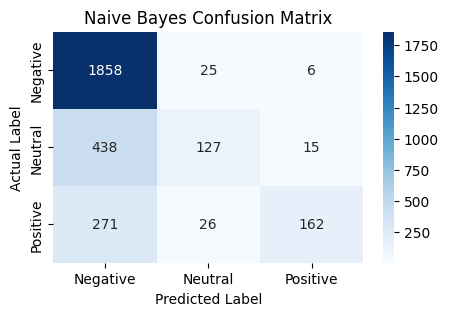

------------------------------
--- Logistic Regression ---
Accuracy: 0.7992
F1-Score: 0.7862



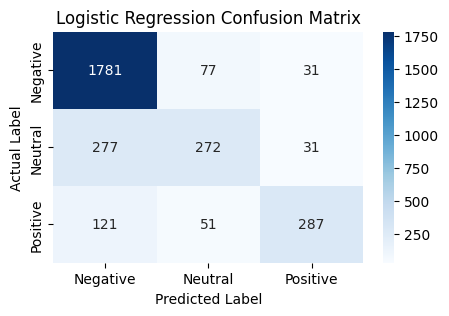

------------------------------
--- Support Vector Machine ---
Accuracy: 0.7947
F1-Score: 0.7858



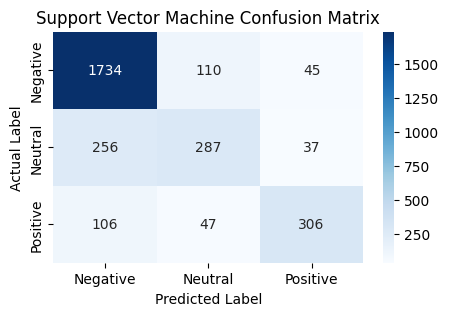

------------------------------


In [10]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

nb_model = MultinomialNB()
lr_model = LogisticRegression(max_iter=1000)
svm_model = SVC(kernel='linear')

print("Training models... this might take a few seconds.\n")
nb_model.fit(X_train_tfidf, y_train)
lr_model.fit(X_train_tfidf, y_train)
svm_model.fit(X_train_tfidf, y_train)


def evaluate_and_plot(model, model_name):
    # Make predictions on the test set
    y_pred = model.predict(X_test_tfidf)


    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"--- {model_name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}\n")

    # Draw the Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=['negative', 'neutral', 'positive'])
    plt.figure(figsize=(5,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
    print("-" * 30)

evaluate_and_plot(nb_model, "Naive Bayes")
evaluate_and_plot(lr_model, "Logistic Regression")
evaluate_and_plot(svm_model, "Support Vector Machine")